## Implementation of Quantum Fourier Transform (QFT)

In [166]:
# !pip install qiskit_aer
%matplotlib inline

import sys
sys.path.append("../src")

from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister
from qiskit import transpile
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
import math
import numpy as np
from qiskit.synthesis.qft import synth_qft_full

## Setup in IBM's Qiskit - Starting point for reconciliation

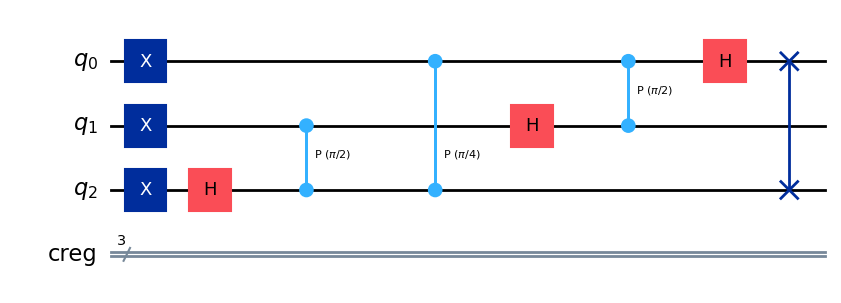

In [167]:
n = 3
x_val = 7 # value to be respresented

q = QuantumRegister(n, 'q')
creg = ClassicalRegister(n, 'creg')
qc = QuantumCircuit(q, creg)

# Prepare |7> = |111>
for i in range(n):
    if (x_val >> i) & 1:
        qc.x(q[i])

# textbook QFT (forward), with swaps
qft = synth_qft_full(num_qubits=n, do_swaps=True)
qc.compose(qft, qubits=range(n), inplace=True)

qc.draw('mpl')

In [168]:
qc.save_statevector()
sim = AerSimulator(method="statevector")
state = sim.run(qc).result().get_statevector()

print(state)

Statevector([ 3.53553391e-01-1.29893408e-16j,
              2.50000000e-01-2.50000000e-01j,
             -1.51542310e-16-3.53553391e-01j,
             -2.50000000e-01-2.50000000e-01j,
             -3.53553391e-01+1.29893408e-16j,
             -2.50000000e-01+2.50000000e-01j,
              1.51542310e-16+3.53553391e-01j,
              2.50000000e-01+2.50000000e-01j],
            dims=(2, 2, 2))


## Individual Gate implementation of the QFT circuit

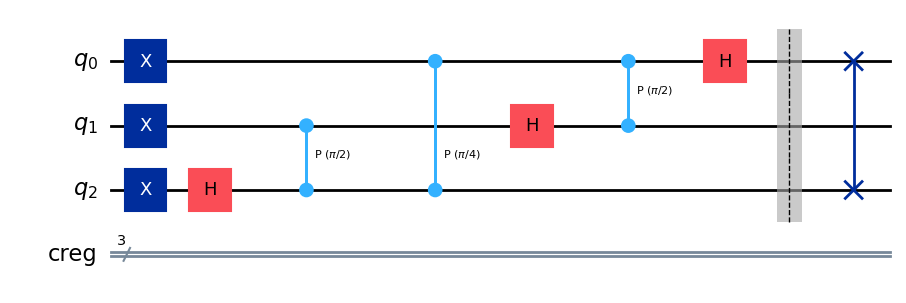

In [181]:
n = 3 # number of qubits
x_val = 7

q = QuantumRegister(n, 'q') 
creg = ClassicalRegister(len(q), 'creg')

qc = QuantumCircuit(q, creg) 

# Prepare the circuit
for i in range(n):
    if (x_val >> i) & 1:
        qc.x(q[i])    

qc.h(q[2])
qc.cp(np.pi/2, 2, 1) # R2 Gate with 2*pi*1j/2*2 = pi*1j/2
qc.cp(np.pi/4, 2, 0) # R3 Gate with 2*pi*1j/2*3 = pi*1j/4

qc.h(q[1])
qc.cp(np.pi/2, 1, 0)

qc.h(q[0])

qc.barrier()
qc.swap(q[0], q[2])

qc.draw('mpl')

In [182]:
qc.save_statevector()
sim = AerSimulator(method="statevector")
state = sim.run(qc).result().get_statevector()

print(state)

Statevector([ 3.53553391e-01-1.29893408e-16j,
              2.50000000e-01-2.50000000e-01j,
             -1.51542310e-16-3.53553391e-01j,
             -2.50000000e-01-2.50000000e-01j,
             -3.53553391e-01+1.29893408e-16j,
             -2.50000000e-01+2.50000000e-01j,
              1.51542310e-16+3.53553391e-01j,
              2.50000000e-01+2.50000000e-01j],
            dims=(2, 2, 2))


This shows that the Qiskit results and this results are the same.

### QFT mathematically (Textbook)

$$
\mathrm{QFT}_N \, |x\rangle
=
\frac{1}{\sqrt{N}}
\sum_{k=0}^{N-1}
\exp\!\left( \frac{2\pi i \, x k}{N} \right)
\, |k\rangle
$$

Example set $|x\rangle = |7\rangle$ with $n=3$ for 3 qubits and $N=2^n=2^3=8$

$$
\mathrm{QFT}_N \, |7\rangle
=
\frac{1}{\sqrt{8}}
\sum_{k=0}^{7}
\exp\!\left( \frac{2\pi i \, 7 k}{8} \right)
\, |k\rangle
$$

Expanding the equation yields

$$
= \frac{1}{\sqrt{8}}
\left(
\exp\!\left( \frac{2\pi i\, 7\cdot 0}{8} \right)\,|000\rangle
+ \exp\!\left( \frac{2\pi i\, 7\cdot 1}{8} \right)\,|001\rangle
+ \exp\!\left( \frac{2\pi i\, 7\cdot 2}{8} \right)\,|010\rangle
+ \exp\!\left( \frac{2\pi i\, 7\cdot 3}{8} \right)\,|011\rangle
+ \exp\!\left( \frac{2\pi i\, 7\cdot 4}{8} \right)\,|100\rangle
+ \exp\!\left( \frac{2\pi i\, 7\cdot 5}{8} \right)\,|101\rangle
+ \exp\!\left( \frac{2\pi i\, 7\cdot 6}{8} \right)\,|110\rangle
+ \exp\!\left( \frac{2\pi i\, 7\cdot 7}{8} \right)\,|111\rangle
\right)
$$

$$
\mathrm{QFT}_N \, |7\rangle
=
\frac{1}{\sqrt(8)}
\Big(
\,e^{2\pi i 0/8}\,|000\rangle
+ \,e^{2\pi i 7/8}\,|001\rangle
+ \,e^{2\pi i 14/8}\,|010\rangle
+ \,e^{2\pi i 21/8}\,|011\rangle
+ \,e^{2\pi i 28/8}\,|100\rangle
+ \,e^{2\pi i 35/8}\,|101\rangle
+ \,e^{2\pi i 42/8}\,|110\rangle
+ \,e^{2\pi i 49/8}\,|111\rangle
\Big)
$$

## Circuit / Dirac Notation for example $|7\rangle$

### Initial circuit

Note that the qubit order in a circuit in Qiskit $|q0,q1,q2\rangle$ is different from the textbook notation $|q2,q1,q0\rangle$.

$$
|\psi_0\rangle = |000\rangle
$$

### Applying X-Gates to get it into $|7\rangle$ state

$$
|\psi_1\rangle
= X|0\rangle_{q_2} \otimes X|0\rangle_{q_1} \otimes X|0\rangle_{q_0}
= |1\rangle_{q_2} \otimes |1\rangle_{q_1} \otimes |1\rangle_{q_0}
= |111\rangle
= |7\rangle
$$

### Hadamard on $q_{2}$

$$
|\psi_2\rangle
= H|1\rangle_{q_2} \otimes |1\rangle_{q_1} \otimes |1\rangle_{q_0}
= |111\rangle
$$

since

$$
H|1\rangle = \frac{1}{\sqrt(2)} \big(|0\rangle - |1\rangle \big)
$$

$$
|\psi_2\rangle
= \frac{1}{\sqrt(2)} \big(|0\rangle - |1\rangle \big) \otimes |1\rangle_{q_1} \otimes |1\rangle_{q_0}
= \frac{1}{\sqrt(2)} \big(|011\rangle - |111\rangle \big)
$$

### Controlled $R_{2}(q_{2}\rightarrow q_{1})$ with phase $\theta=2\pi/4$

$R_{k}$ is applying a phase if both the control and target qubits are in 1 state.

$$
R_2
=
\begin{pmatrix}
1 & 0 \\
0 & e^{2\pi\,i/2^k}
\end{pmatrix}
$$

For example $R_2$ applies a phase $\theta=\frac{2 \pi}{4}=\pi/2$.

$$
|\psi_3\rangle
= \frac{1}{\sqrt(2)} \big(|011\rangle - e^{2\,\pi i/4}|111\rangle \big)
$$

### Controlled $R_{3}(q_{2}\rightarrow q_{0})$ with phase $\theta=2\pi/8$

R3 is applied on the states where both $q_2$ and $q_0$ are in 1 state

$$
|\psi_4\rangle
= \frac{1}{\sqrt(2)} \big(|011\rangle - e^{2\,\pi i/8}e^{2\,\pi i/4}|111\rangle \big)
$$

### Hadamard on $q_{1}$

$$
|\psi_5\rangle
= \frac{1}{\sqrt(4)} \big( 
|001\rangle 
- |011\rangle
- e^{2\,\pi i/8}e^{2\,\pi i/4}|101\rangle
+ e^{2\,\pi i/8}e^{2\,\pi i/4}|111\rangle
\big)
$$

### Controlled $R_{2}(q_{1}\rightarrow q_{0})$ with phase $\theta=2\pi/4$

R2 is applied on the states where both $q_1$ and $q_0$ are in 1 state

$$
|\psi_6\rangle
= \frac{1}{\sqrt(4)} \big( 
|001\rangle 
- e^{2\,\pi i/4}|011\rangle
- e^{2\,\pi i/8}e^{2\,\pi i/4}|101\rangle
+ e^{2\,\pi i/4}e^{2\,\pi i/8}e^{2\,\pi i/4}|111\rangle
\big)
$$

### Hadamard on $q_{0}$

Remember the following which determines the sign

$$
H|0\rangle = \frac{1}{\sqrt(2)} \big(|0\rangle + |1\rangle \big)
$$

and

$$
H|1\rangle = \frac{1}{\sqrt(2)} \big(|0\rangle - |1\rangle \big)
$$

the equations becomes

$$
|\psi_7\rangle
= \frac{1}{\sqrt(8)} \big( 
|000\rangle 
- |001\rangle 
- e^{2\,\pi i/4}|010\rangle
+ e^{2\,\pi i/4}|011\rangle
- e^{2\,\pi i/8}e^{2\,\pi i/4}|100\rangle
+ e^{2\,\pi i/8}e^{2\,\pi i/4}|101\rangle
+ e^{2\,\pi i/4}e^{2\,\pi i/8}e^{2\,\pi i/4}|110\rangle
- e^{2\,\pi i/4}e^{2\,\pi i/8}e^{2\,\pi i/4}|111\rangle
\big)
$$

Swap qubits at the end of QFT for reversed ordering
$$
|\psi_7\rangle
= \frac{1}{\sqrt(8)} \big( 
|000\rangle 
- e^{2\,\pi i/8}e^{2\,\pi i/4}|001\rangle
- e^{2\,\pi i/4}|010\rangle
+ e^{2\,\pi i/4}e^{2\,\pi i/8}e^{2\,\pi i/4}|011\rangle
- |100\rangle 
+ e^{2\,\pi i/8}e^{2\,\pi i/4}|101\rangle
+ e^{2\,\pi i/4}|110\rangle
- e^{2\,\pi i/4}e^{2\,\pi i/8}e^{2\,\pi i/4}|111\rangle
\big)
$$

Substitute $(-)$ sign with $\pi i$

$$
|\psi_7\rangle
= \frac{1}{\sqrt(8)} \big( 
|000\rangle 
+ e^{i\pi}e^{2\,\pi i/8}e^{2\,\pi i/4}|001\rangle
+ e^{i\pi}e^{2\,\pi i/4}|010\rangle
+ e^{2\,\pi i/4}e^{2\,\pi i/8}e^{2\,\pi i/4}|011\rangle
+ e^{i\pi}|100\rangle 
+ e^{2\,\pi i/8}e^{2\,\pi i/4}|101\rangle
+ e^{2\,\pi i/4}|110\rangle
+ e^{i\pi}e^{2\,\pi i/4}e^{2\,\pi i/8}e^{2\,\pi i/4}|111\rangle
\big)
$$

simplifying yields the final result

$$
|\psi_7\rangle
= \frac{1}{\sqrt(8)} \big( 
|000\rangle 
+ e^{2\,\pi i 7/8}|001\rangle
+ e^{2\,\pi i 6/8}|010\rangle
+ e^{2\,\pi i 5/8}|011\rangle
+ e^{2\,\pi i 4/8}|100\rangle 
+ e^{2\,\pi i 3/8}|101\rangle
+ e^{2\,\pi i 2/8}|110\rangle
+ e^{2\,\pi i 9/8}|111\rangle
\big)
$$

---

### How does this compare to the general QFT textbook pattern

$$
\mathrm{QFT}_N\,|x\rangle
=
\bigotimes_{j=0}^{2}
\frac{1}{\sqrt{2}}
\left(
|0\rangle
+
e^{\,2\pi i\, x / 2^{\,j+1}}\,
|1\rangle
\right)_{q_j}
$$

For our example $N=8$ and $x=7$ we get

$$
\mathrm{QFT}_8\,|7\rangle
=
\frac{1}{\sqrt{2}}
\left(
|0\rangle
+
e^{\,2\pi i\, 7 / 2^{\,1}}\,
|1\rangle
\right)_{q_0}
\bigotimes
\frac{1}{\sqrt{2}}
\left(
|0\rangle
+
e^{\,2\pi i\, 7 / 2^{\,2}}\,
|1\rangle
\right)_{q_1}
\bigotimes
\frac{1}{\sqrt{2}}
\left(
|0\rangle
+
e^{\,2\pi i\, 7 / 2^{\,3}}\,
|1\rangle
\right)_{q_2}
$$

Expand first term

$$
=
\frac{1}{\sqrt{4}}
\left(
|00\rangle
+
e^{2\pi i\, \frac{7}{4}}\,|01\rangle
+
e^{2\pi i\, \frac{7}{2}}\,|10\rangle
+
e^{2\pi i\, \frac{21}{4}}\,|11\rangle
\right)
\;\otimes\;
\frac{1}{\sqrt{2}}
\left(
|0\rangle
+
e^{2\pi i\, \frac{7}{4}}\,|1\rangle
\right)
$$

Expand second term

$$
\mathrm{QFT}_8\,|7\rangle
=
\frac{1}{\sqrt{8}}\Big(
|000\rangle
+ e^{2\pi i\,\frac{7}{8}}\,|001\rangle
+ e^{2\pi i\,\frac{14}{8}}\,|010\rangle
+ e^{2\pi i\,\frac{21}{8}}\,|011\rangle
+ e^{2\pi i\,\frac{28}{8}}\,|100\rangle
+ e^{2\pi i\,\frac{35}{8}}\,|101\rangle
+ e^{2\pi i\,\frac{42}{8}}\,|110\rangle
+ e^{2\pi i\,\frac{49}{8}}\,|111\rangle
\Big)
$$

---

### How does the above compare the Textbook version?

To get to the same results we must reduce the exponents modulo 1. Adding an integer to the exponent multiplies by $e^{2 \pi i k}$

$$
|\psi_7\rangle
= \frac{1}{\sqrt(8)} \big( 
|000\rangle 
+ e^{2\,\pi i 7/8}|001\rangle
+ e^{2\,\pi i 6/8}|010\rangle
+ e^{2\,\pi i 5/8}|011\rangle
+ e^{2\,\pi i 4/8}|100\rangle 
+ e^{2\,\pi i 3/8}|101\rangle
+ e^{2\,\pi i 2/8}|110\rangle
+ e^{2\,\pi i 9/8}|111\rangle
\big)
$$

Reduction modulo 1, or in this case reduction modulo $8/8$. Recall that

- $e^{i\theta}=cos(\theta)+i sin(\theta)$
- $\pi$ is a half circle, $2\pi$ a full circle
- If we "reduce" $e^{2\pi i 14/8}$ "by one circle" $e^{2\pi i 14/8 - 2\pi i 1}$ or $e^{2\pi i 14/8 - 2\pi i 8/8}$, we get $e^{2\pi i 6/8}$ and therefore the same result as above
- Similarly for all other factors in the textbook result, if we for example reduce $e^{2\pi i 28/8}$ by modulo 1, we get $e^{2\pi i 28/8 - 3*(8/8)}$ we get $e^{2\pi i 4/8}$ as in the solution above when applying the gates

$$
|\psi_7\rangle
= \frac{1}{\sqrt(8)} \big( 
|000\rangle 
+ e^{2\,\pi i 7/8}|001\rangle
+ e^{2\,\pi i 6/8}|010\rangle
+ e^{2\,\pi i 5/8}|011\rangle
+ e^{2\,\pi i 4/8}|100\rangle 
+ e^{2\,\pi i 3/8}|101\rangle
+ e^{2\,\pi i 2/8}|110\rangle
+ e^{2\,\pi i 9/8}|111\rangle
\big)
$$

This shows that both versions are equivalent.

### Plotting the amplitudes

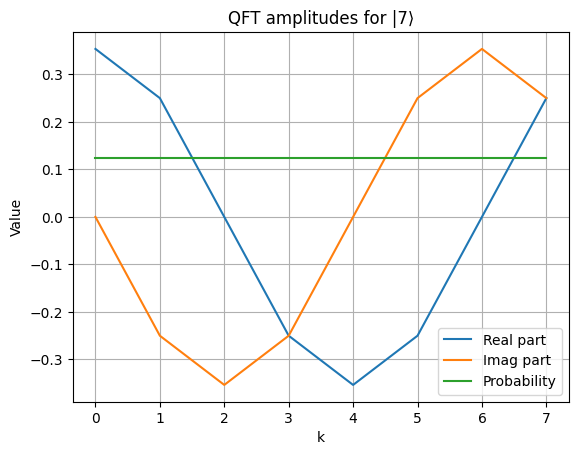

In [183]:
n = 3
N = 2**n

# QFT amplitudes for |7>
y = np.array([(1/np.sqrt(N)) * np.exp(2*np.pi*1j*7*k/N) for k in range(N)])

# Probabilities
prob = np.abs(y)**2

plt.plot(range(N), y.real, label="Real part")
plt.plot(range(N), y.imag, label="Imag part")
plt.plot(range(N), prob, label="Probability")

plt.xlabel("k")
plt.ylabel("Value")
plt.title("QFT amplitudes for |7⟩")
plt.legend()
plt.grid(True)
plt.show()

## What's next

Next step is to look at Modular QFT that is relevant for Shor's algorithm.